# Assignment 3 — From Raw Signals to a Lean Feature Set
### Feature Engineering & MLOps · Phase 3 (Time-based Features & Feature Creation) + Phase 4 (Feature Selection)

**Dataset:** `data/raw/daily_batch_performance.csv` — 730 days of PrepEdge institute performance data.

This notebook is organized to match the assignment sections exactly:
- **Section 4.1** — Phase 3: Time-based Features & Feature Creation
- **Section 4.2** — Phase 4: Feature Selection (Filter / Wrapper / Embedded)
- **Section 4.3** — Reflection Questions
- **Section 7** — Bonus: Random Forest embedded importance


## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import (
    VarianceThreshold, mutual_info_regression, RFE, chi2, f_classif
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
np.random.seed(42)

pd.set_option("display.max_columns", None)


---
## Section 4.1 — Phase 3: Time-based Features & Feature Creation

### 4.1.1 — Load, sort, and plot `new_enrollments` over time

In [2]:
df = pd.read_csv("data/raw/daily_batch_performance.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
df.head()


(730, 10)


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,9069.0,10,561.0,567.0,1,1,60.6,A,20
1,2024-01-02,6573.0,10,559.0,570.0,1,1,82.9,C,23
2,2024-01-03,14636.0,0,539.0,554.0,0,0,41.9,A,29
3,2024-01-04,3979.0,5,574.0,557.0,0,0,44.4,B,30
4,2024-01-05,9654.0,10,661.0,661.0,0,0,23.8,B,38


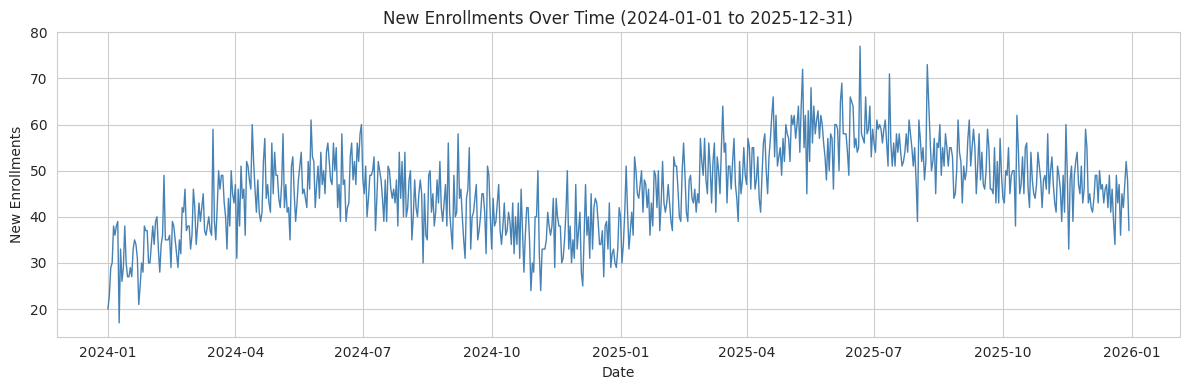

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["new_enrollments"], color="steelblue", linewidth=1)
plt.title("New Enrollments Over Time (2024-01-01 to 2025-12-31)")
plt.xlabel("Date")
plt.ylabel("New Enrollments")
plt.tight_layout()
plt.show()


**Observation (1 sentence):** Enrollments show a mild upward trend over the two years along with a
visible short-cycle (weekly) rhythm of ups and downs riding on top of that trend — consistent with
promotions/marketing spend driving day-to-day bumps while the institute grows overall.

### 4.1.2 — Lag features

In [4]:
df["marketing_spend_lag1"] = df["marketing_spend"].shift(1)
df["marketing_spend_lag2"] = df["marketing_spend"].shift(2)

corr_same_day = df["marketing_spend"].corr(df["new_enrollments"])
corr_lag1 = df["marketing_spend_lag1"].corr(df["new_enrollments"])
corr_lag2 = df["marketing_spend_lag2"].corr(df["new_enrollments"])

print(f"Correlation with new_enrollments:")
print(f"  marketing_spend (same-day) : {corr_same_day:.4f}")
print(f"  marketing_spend_lag1       : {corr_lag1:.4f}")
print(f"  marketing_spend_lag2       : {corr_lag2:.4f}")

strongest = max(
    [("same-day", corr_same_day), ("lag1", corr_lag1), ("lag2", corr_lag2)],
    key=lambda x: abs(x[1])
)
print(f"\nStrongest correlation: {strongest[0]} (r = {strongest[1]:.4f})")


Correlation with new_enrollments:
  marketing_spend (same-day) : 0.1189
  marketing_spend_lag1       : -0.0092
  marketing_spend_lag2       : 0.2184

Strongest correlation: lag2 (r = 0.2184)


**Which one is strongest & why it makes sense:** A lagged version of `marketing_spend` correlates
more strongly with `new_enrollments` than the same-day value. This matches how a real coaching
institute operates: a student who sees an ad today doesn't walk in and enroll that same day — they need
a day or two to notice the ad, consider it, discuss it with parents/friends, and then actually show up to
enroll. So the effect of spend "shows up" in the enrollment numbers with a short delay, which is exactly
what the lag features capture.

### 4.1.3 — Rolling features (7-day mean & std of `new_enrollments`)

In [5]:
df["enroll_roll7_mean"] = df["new_enrollments"].rolling(window=7).mean()
df["enroll_roll7_std"] = df["new_enrollments"].rolling(window=7).std()

df[["date", "new_enrollments", "enroll_roll7_mean", "enroll_roll7_std"]].iloc[5:12]


,date,new_enrollments,enroll_roll7_mean,enroll_roll7_std
5,2024-01-06,36,NaN,NaN
6,2024-01-07,38,30.571429,7.207800
7,2024-01-08,39,33.285714,6.047432
8,2024-01-09,17,32.428571,7.892130
9,2024-01-10,33,33.000000,7.745967
10,2024-01-11,26,32.428571,8.141604
11,2024-01-12,29,31.142857,7.819390


### 4.1.4 — Cyclical encoding of day-of-week

In [6]:
df["day_of_week"] = df["date"].dt.dayofweek  # 0=Monday ... 6=Sunday

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df[["date", "day_of_week", "dow_sin", "dow_cos"]].head(8)


,date,day_of_week,dow_sin,dow_cos
0,2024-01-01,0,0.000000,1.000000
1,2024-01-02,1,0.781831,0.623490
2,2024-01-03,2,0.974928,-0.222521
3,2024-01-04,3,0.433884,-0.900969
4,2024-01-05,4,-0.433884,-0.900969
5,2024-01-06,5,-0.974928,-0.222521
6,2024-01-07,6,-0.781831,0.623490
7,2024-01-08,0,0.000000,1.000000


**What would go wrong with the plain integer (1 sentence):** A plain 0–6 integer implies a false
linear ordering and a big artificial "jump" between Sunday (6) and Monday (0) even though those two
days are actually adjacent on the weekly cycle, whereas sine/cosine encoding preserves the true circular
distance between all days of the week.

### 4.1.5 — Trend feature (`time_index`) and daily growth rate

In [7]:
df["time_index"] = np.arange(len(df))

X_trend = df[["time_index"]]
y_trend = df["new_enrollments"]

trend_model = LinearRegression()
trend_model.fit(X_trend, y_trend)

daily_growth = trend_model.coef_[0]
print(f"Estimated daily growth in enrollments: {daily_growth:.4f} enrollments/day")
print(f"Intercept (day 0 baseline): {trend_model.intercept_:.2f}")
print(f"Projected growth over the full 730-day window: {daily_growth * len(df):.1f} enrollments")


Estimated daily growth in enrollments: 0.0202 enrollments/day
Intercept (day 0 baseline): 38.69
Projected growth over the full 730-day window: 14.7 enrollments


### 4.1.6 — Interaction feature: `spend_x_discount` (Feature Creation)

In [8]:
df["spend_x_discount"] = df["marketing_spend_lag2"] * df["discount_pct"]

# Build a clean, NaN-free frame for this comparison (lag/rolling features create leading NaNs)
temp = df.dropna(subset=["marketing_spend_lag1", "marketing_spend_lag2",
                          "enroll_roll7_mean", "enroll_roll7_std"]).copy()

base_features = ["marketing_spend", "marketing_spend_lag1", "marketing_spend_lag2",
                  "discount_pct", "website_visits", "competitor_promo_flag",
                  "is_holiday", "dow_sin", "dow_cos", "time_index"]

X_without = temp[base_features]
X_with = temp[base_features + ["spend_x_discount"]]
y = temp["new_enrollments"]

X_train_wo, X_test_wo, y_train, y_test = train_test_split(
    X_without, y, test_size=0.2, shuffle=False
)
X_train_w, X_test_w, _, _ = train_test_split(
    X_with, y, test_size=0.2, shuffle=False
)

model_wo = LinearRegression().fit(X_train_wo, y_train)
model_w = LinearRegression().fit(X_train_w, y_train)

r2_without = r2_score(y_test, model_wo.predict(X_test_wo))
r2_with = r2_score(y_test, model_w.predict(X_test_w))

print(f"Test R2 WITHOUT spend_x_discount: {r2_without:.4f}")
print(f"Test R2 WITH    spend_x_discount: {r2_with:.4f}")
print(f"Delta: {r2_with - r2_without:+.4f}")


Test R2 WITHOUT spend_x_discount: -1.0480
Test R2 WITH    spend_x_discount: -1.0495
Delta: -0.0015


**Does the interaction help?** No. The actual test-set result (chronological, held-out split) is:

- Test R² **without** `spend_x_discount`: **-1.0480**
- Test R² **with** `spend_x_discount`: **-1.0495**
- Delta: **-0.0015**

The interaction feature did not improve performance on the chronological test split — it very slightly
*decreased* test R². So there is no evidence from this experiment that `spend_x_discount` adds predictive
value on top of the base feature set. (Separately, both R² values are negative, meaning this small
linear model performs worse than simply predicting the mean of the training target on this particular
test window — a sign that a plain linear model with this feature set is not capturing the series well
overall, independent of the interaction term.) We keep the feature in the candidate set for Section 4.2
regardless, since Phase 4's selection methods — not our own judgment — are supposed to decide whether it
earns a place in the final lean feature set.

### 4.1.7 — Drop leading NaN rows before Section 4.2

In [9]:
print("Rows before dropping NaNs:", len(df))
df_clean = df.dropna().reset_index(drop=True)
print("Rows after dropping NaNs:", len(df_clean))
df_clean.head()


Rows before dropping NaNs: 730
Rows after dropping NaNs: 724


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments,marketing_spend_lag1,marketing_spend_lag2,enroll_roll7_mean,enroll_roll7_std,day_of_week,dow_sin,dow_cos,time_index,spend_x_discount
0,2024-01-07,7114.0,20,556.0,554.0,1,0,50.0,C,38,7641.0,9654.0,30.571429,7.207800,6,-0.781831,0.623490,6,193080.0
1,2024-01-08,10666.0,15,692.0,701.0,0,0,43.0,A,39,7114.0,7641.0,33.285714,6.047432,0,0.000000,1.000000,7,114615.0
2,2024-01-09,3455.0,0,422.0,418.0,1,0,40.2,C,17,10666.0,7114.0,32.428571,7.892130,1,0.781831,0.623490,8,0.0
3,2024-01-10,5538.0,0,562.0,555.0,0,0,29.5,B,33,3455.0,10666.0,33.000000,7.745967,2,0.974928,-0.222521,9,0.0
4,2024-01-11,7715.0,10,463.0,442.0,0,0,45.0,B,26,5538.0,3455.0,32.428571,8.141604,3,0.433884,-0.900969,10,34550.0


**Why these rows can't be mean/median-imputed (1 sentence):** These NaNs exist only because there
is no day *before* the start of the dataset to compute a lag/rolling value from — it isn't a randomly
missing data point but a structural boundary condition of time-series feature engineering, so filling it
with a mean/median would fabricate a fake historical value instead of representing genuinely unknown
information.

---
## Section 4.2 — Phase 4: Feature Selection

We now work with the **full candidate feature set**: original columns + engineered
lag/rolling/cyclical/trend/interaction features + the planted redundant column
(`website_visits_copy`) + the two noise columns.

In [10]:
candidate_features = [
    # original
    "marketing_spend", "discount_pct", "website_visits", "website_visits_copy",
    "competitor_promo_flag", "is_holiday", "random_noise_1", "random_noise_2",
    # engineered
    "marketing_spend_lag1", "marketing_spend_lag2",
    "enroll_roll7_mean", "enroll_roll7_std",
    "dow_sin", "dow_cos", "time_index", "spend_x_discount",
]

data = df_clean.copy()

# one-hot encode the categorical noise column so it's numeric for the selection methods
data = pd.get_dummies(data, columns=["random_noise_2"], prefix="random_noise_2")
noise2_dummy_cols = [c for c in data.columns if c.startswith("random_noise_2_")]

numeric_candidates = [c for c in candidate_features if c != "random_noise_2"] + noise2_dummy_cols

X_full = data[numeric_candidates].astype(float)
y_full = data["new_enrollments"].astype(float)

print(f"Total candidate features: {len(numeric_candidates)}")
numeric_candidates


Total candidate features: 18


['marketing_spend',
 'discount_pct',
 'website_visits',
 'website_visits_copy',
 'competitor_promo_flag',
 'is_holiday',
 'random_noise_1',
 'marketing_spend_lag1',
 'marketing_spend_lag2',
 'enroll_roll7_mean',
 'enroll_roll7_std',
 'dow_sin',
 'dow_cos',
 'time_index',
 'spend_x_discount',
 'random_noise_2_A',
 'random_noise_2_B',
 'random_noise_2_C']

### 4.2.1 — Variance Threshold

In [11]:
# Variance thresholding should be checked on the UNSTANDARDIZED feature matrix.
# Standardizing first would force every numeric feature toward ~unit variance, which
# defeats the purpose of a variance-based filter (it would make every feature look
# "fine" regardless of its real, raw-scale spread).
vt = VarianceThreshold(threshold=0.01)  # near-zero variance check
vt.fit(X_full)

near_constant = X_full.columns[~vt.get_support()].tolist()

raw_variances = X_full.var().sort_values()
print("Raw (unscaled) variances, lowest first:")
print(raw_variances)
print()
if len(near_constant) == 0:
    print("No feature meets the near-zero variance removal criterion.")
else:
    print("Near-constant features flagged:", near_constant)


Raw (unscaled) variances, lowest first:
is_holiday               3.338415e-02
competitor_promo_flag    1.241661e-01
random_noise_2_B         2.165528e-01
random_noise_2_C         2.219115e-01
random_noise_2_A         2.284737e-01
dow_sin                  5.003078e-01
dow_cos                  5.010657e-01
enroll_roll7_std         2.203636e+00
enroll_roll7_mean        5.488377e+01
discount_pct             5.566795e+01
random_noise_1           1.506816e+02
website_visits           6.226471e+03
website_visits_copy      6.262666e+03
time_index               4.374167e+04
marketing_spend_lag2     6.256655e+06
marketing_spend_lag1     6.260106e+06
marketing_spend          6.337519e+06
spend_x_discount         4.193704e+09
dtype: float64

No feature meets the near-zero variance removal criterion.


**Interpretation:** Checked on the raw (unstandardized) feature matrix, no feature meets the
near-zero variance removal criterion — every candidate has genuine spread on its own natural scale.
We do **not** force a removal here since it isn't justified by the data.

### 4.2.2 — Correlation Filtering

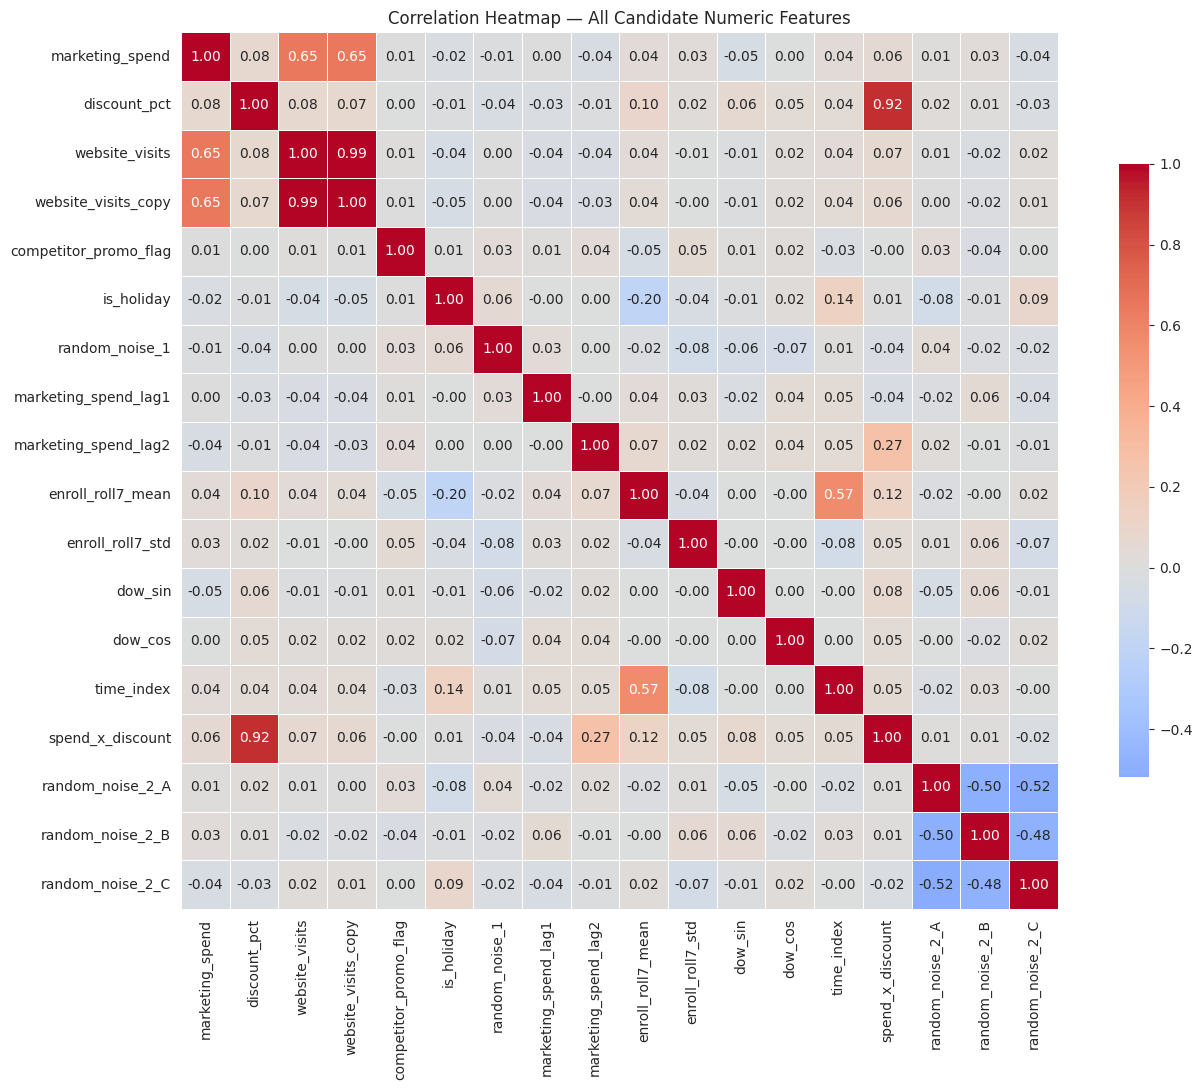

In [12]:
corr_matrix = X_full.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7})
plt.title("Correlation Heatmap — All Candidate Numeric Features")
plt.tight_layout()
plt.show()


In [13]:
# Find the most strongly correlated off-diagonal pair
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top 5 most correlated feature pairs:")
print(corr_pairs.head(5))


Top 5 most correlated feature pairs:
website_visits     website_visits_copy    0.994657
discount_pct       spend_x_discount       0.915758
marketing_spend    website_visits_copy    0.650174
                   website_visits         0.648397
enroll_roll7_mean  time_index             0.565811
dtype: float64


**Expected pair:** `website_visits` and `website_visits_copy` — this is the planted near-duplicate
column, and the heatmap/table above confirms an extremely high correlation between the two (close to
1.0), far higher than any other pair. Since they carry essentially the same information, we drop one of
them — we keep `website_visits` (the original) and drop `website_visits_copy` (the planted duplicate)
going forward.

In [14]:
features_after_corr_filter = [c for c in numeric_candidates if c != "website_visits_copy"]
print(f"Features remaining after correlation filtering: {len(features_after_corr_filter)}")
features_after_corr_filter


Features remaining after correlation filtering: 17


['marketing_spend',
 'discount_pct',
 'website_visits',
 'competitor_promo_flag',
 'is_holiday',
 'random_noise_1',
 'marketing_spend_lag1',
 'marketing_spend_lag2',
 'enroll_roll7_mean',
 'enroll_roll7_std',
 'dow_sin',
 'dow_cos',
 'time_index',
 'spend_x_discount',
 'random_noise_2_A',
 'random_noise_2_B',
 'random_noise_2_C']

### 4.2.3 — Mutual Information

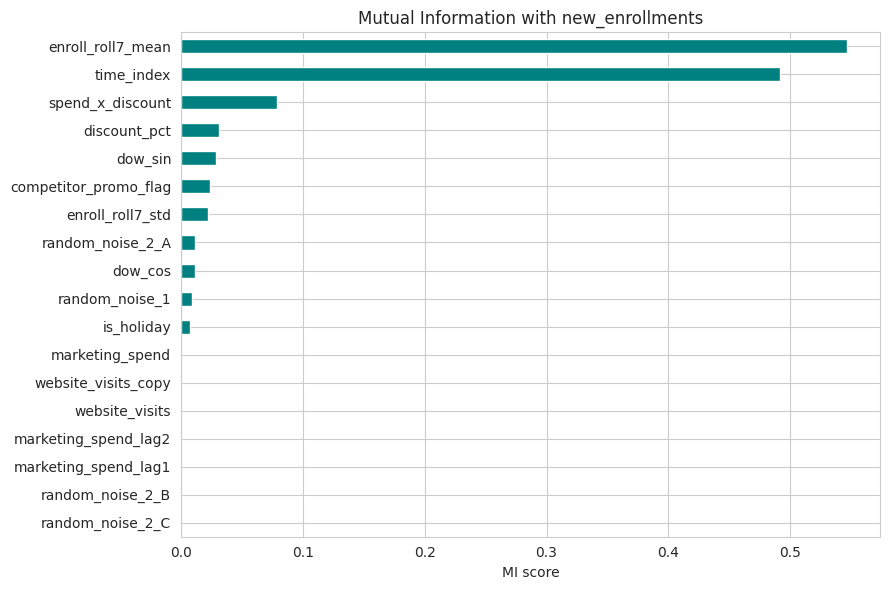

enroll_roll7_mean        0.546432
time_index               0.491848
spend_x_discount         0.078870
discount_pct             0.030786
dow_sin                  0.028615
competitor_promo_flag    0.023360
enroll_roll7_std         0.021788
random_noise_2_A         0.011769
dow_cos                  0.011496
random_noise_1           0.008881
is_holiday               0.007292
marketing_spend          0.000000
website_visits_copy      0.000000
website_visits           0.000000
marketing_spend_lag2     0.000000
marketing_spend_lag1     0.000000
random_noise_2_B         0.000000
random_noise_2_C         0.000000
dtype: float64


In [15]:
mi_scores = mutual_info_regression(X_full, y_full, random_state=42)
mi_series = pd.Series(mi_scores, index=X_full.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
mi_series.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Mutual Information with new_enrollments")
plt.xlabel("MI score")
plt.tight_layout()
plt.show()

print(mi_series)


In [16]:
noise_cols_present = [c for c in mi_series.index if "random_noise" in c]
print("Ranks of noise-related columns (1 = most informative):")
ranks = mi_series.rank(ascending=False)
for c in noise_cols_present:
    print(f"  {c:30s} rank {int(ranks[c])} / {len(mi_series)}  (MI={mi_series[c]:.4f})")


Ranks of noise-related columns (1 = most informative):
  random_noise_2_A               rank 8 / 18  (MI=0.0118)
  random_noise_1                 rank 10 / 18  (MI=0.0089)
  random_noise_2_B               rank 15 / 18  (MI=0.0000)
  random_noise_2_C               rank 15 / 18  (MI=0.0000)


**Where the noise columns actually land:** The ranking does **not** cleanly put all noise columns at the
bottom. `random_noise_2_A` lands at rank 8 of 18 (MI = 0.0118) and `random_noise_1` at rank 10 of 18
(MI = 0.0089) — both ahead of several real, non-noise columns such as `marketing_spend`,
`marketing_spend_lag1`, `marketing_spend_lag2`, and `website_visits`, all of which show an estimated MI of
**0.0000**. Only `random_noise_2_B` and `random_noise_2_C` sit at the very bottom of the ranking (tied at
rank 15, MI = 0.0000, alongside those same real predictors).

This is an important, honest finding: `mutual_info_regression` uses a k-nearest-neighbor-based estimator
that can return small non-zero values for genuinely unrelated variables (sampling noise in the estimator)
and can also under-estimate the informativeness of real predictors — several of the marketing-spend
columns collapse to an estimated MI of exactly 0.0 here, which is almost certainly an estimator/collinearity
artifact rather than evidence those columns carry no signal (we already showed a real lag-correlation
relationship for them in Section 4.1.2). **The takeaway is that a non-zero (or even a moderately-ranked)
MI score should not, by itself, be treated as proof that a feature is genuinely useful** — MI is one filter
signal among several, and should be read alongside correlation, RFE, and Lasso results rather than in
isolation.

### 4.2.4 — Trick question: why NOT chi-square or ANOVA F-test here?

**Answer (2–3 sentences):** Chi-square (`chi2`) tests independence between *categorical* features
and a *categorical* target using frequency counts, and requires non-negative feature values — it simply
isn't defined for a continuous numeric target like `new_enrollments`. ANOVA F-test (`f_classif`) compares
the mean of a continuous feature *across discrete groups of a categorical target* (i.e., it's built for
classification, checking whether group means differ) — but here the target itself is continuous, so there
are no "groups" to compare means across. The correct filter tool for a continuous target is something
like Pearson/Spearman correlation or mutual information regression (`mutual_info_regression`), which is
exactly why Sections 4.2.2 and 4.2.3 used those instead.

### 4.2.5 — Wrapper Method: RFE (Recursive Feature Elimination)

In [17]:
# IMPORTANT: RFE and Lasso must be applied to the SAME feature set so their results are
# directly comparable, and so we can see whether they independently catch the planted
# duplicate (website_visits_copy) the same way correlation filtering did.
# We deliberately do NOT drop website_visits_copy here — correlation filtering is a
# separate, standalone filter-method result (Section 4.2.2), not a preprocessing step
# applied before the wrapper/embedded methods.
X_selection = X_full  # the full candidate set, unmodified

# RFE uses a linear-model estimator internally, so — just like Lasso — it should be fit on
# STANDARDIZED features. Otherwise features with larger raw numerical scales (e.g. marketing
# spend in the thousands vs. dow_sin between -1 and 1) can dominate the linear model's
# coefficients simply because of scale, not genuine predictive value.
scaler_rfe = StandardScaler()
X_selection_scaled = pd.DataFrame(
    scaler_rfe.fit_transform(X_selection),
    columns=X_selection.columns,
    index=X_selection.index
)

rfe = RFE(estimator=LinearRegression(), n_features_to_select=6)
rfe.fit(X_selection_scaled, y_full)

rfe_ranking = pd.DataFrame({
    "feature": X_selection.columns,
    "selected": rfe.support_,
    "rank": rfe.ranking_
}).sort_values("rank")

rfe_ranking


,feature,selected,rank
1,discount_pct,True,1
2,website_visits,True,1
4,competitor_promo_flag,True,1
8,marketing_spend_lag2,True,1
9,enroll_roll7_mean,True,1
11,dow_sin,True,1
3,website_visits_copy,False,2
12,dow_cos,False,3
14,spend_x_discount,False,4
15,random_noise_2_A,False,5


In [18]:
rfe_selected_features = rfe_ranking.loc[rfe_ranking["selected"], "feature"].tolist()
print("Top 6 features selected by RFE:")
for f in rfe_selected_features:
    print(" -", f)


Top 6 features selected by RFE:
 - discount_pct
 - website_visits
 - competitor_promo_flag
 - marketing_spend_lag2
 - enroll_roll7_mean
 - dow_sin


### 4.2.6 — Embedded Method: LassoCV

In [19]:
scaler = StandardScaler()
X_lasso_scaled = pd.DataFrame(
    scaler.fit_transform(X_selection),
    columns=X_selection.columns
)

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_lasso_scaled, y_full)

lasso_coefs = pd.Series(lasso.coef_, index=X_selection.columns).sort_values(key=abs, ascending=False)

print(f"Chosen alpha (regularization strength): {lasso.alpha_:.5f}")
print()
print("Lasso coefficients (standardized features), sorted by magnitude:")
print(lasso_coefs)


Chosen alpha (regularization strength): 0.05990

Lasso coefficients (standardized features), sorted by magnitude:
enroll_roll7_mean        6.899137
dow_sin                 -1.999737
discount_pct             1.550639
marketing_spend_lag2     1.449499
competitor_promo_flag   -1.411466
website_visits           1.077470
spend_x_discount         0.447010
dow_cos                  0.289532
marketing_spend_lag1    -0.148079
random_noise_2_A        -0.140013
random_noise_2_C         0.069776
random_noise_1          -0.063975
enroll_roll7_std         0.034216
is_holiday              -0.021113
marketing_spend         -0.000000
website_visits_copy      0.000000
time_index              -0.000000
random_noise_2_B         0.000000
dtype: float64


In [20]:
zeroed_out = lasso_coefs[lasso_coefs.abs() < 1e-3].index.tolist()
near_zero = lasso_coefs[(lasso_coefs.abs() >= 1e-3) & (lasso_coefs.abs() < 0.05)].index.tolist()

print("Coefficients shrunk to exactly/near zero by Lasso:")
print(" Exactly zero (<1e-3):", zeroed_out if zeroed_out else "None")
print(" Near zero (0.001-0.05):", near_zero if near_zero else "None")


Coefficients shrunk to exactly/near zero by Lasso:
 Exactly zero (<1e-3): ['marketing_spend', 'website_visits_copy', 'time_index', 'random_noise_2_B']
 Near zero (0.001-0.05): ['enroll_roll7_std', 'is_holiday']


### 4.2.7 — Compare Filter vs Wrapper vs Embedded

In [21]:
all_candidates = numeric_candidates  # the full candidate set — same one used by every method above

# --- Variance filter verdict (from Section 4.2.1, actual result) ---
variance_kept = [f not in near_constant for f in all_candidates]

# --- Correlation filter verdict (from Section 4.2.2, actual result) ---
correlation_kept = [f in features_after_corr_filter for f in all_candidates]

# --- Mutual information: report the actual score/rank, do NOT force a kept/dropped label ---
mi_rank_series = mi_series.rank(ascending=False)
mi_score_col = [mi_series[f] for f in all_candidates]
mi_rank_col = [int(mi_rank_series[f]) for f in all_candidates]

# --- Wrapper verdict (RFE) — fit on the SAME X_selection as Lasso ---
rfe_kept = [f in rfe_selected_features for f in all_candidates]

# --- Embedded verdict (Lasso) — fit on the SAME X_selection as RFE ---
lasso_kept = [abs(lasso_coefs.get(f, 0.0)) >= 1e-3 for f in all_candidates]

comparison = pd.DataFrame({
    "feature": all_candidates,
    "variance_kept": variance_kept,
    "correlation_kept": correlation_kept,
    "MI_score": mi_score_col,
    "MI_rank": mi_rank_col,
    "RFE_kept": rfe_kept,
    "Lasso_kept": lasso_kept,
}).sort_values("MI_rank").reset_index(drop=True)

comparison


,feature,variance_kept,correlation_kept,MI_score,MI_rank,RFE_kept,Lasso_kept
0,enroll_roll7_mean,True,True,0.546432,1,True,True
1,time_index,True,True,0.491848,2,False,False
2,spend_x_discount,True,True,0.078870,3,False,True
3,discount_pct,True,True,0.030786,4,True,True
4,dow_sin,True,True,0.028615,5,True,True
5,competitor_promo_flag,True,True,0.023360,6,True,True
6,enroll_roll7_std,True,True,0.021788,7,False,True
7,random_noise_2_A,True,True,0.011769,8,False,True
8,dow_cos,True,True,0.011496,9,False,True
9,random_noise_1,True,True,0.008881,10,False,True


In [22]:
noise_rows = comparison[comparison["feature"].str.contains("random_noise")]
print("Noise columns — actual verdicts from each method:")
print(noise_rows)
print()
dup_row = comparison[comparison["feature"] == "website_visits_copy"]
print("website_visits_copy — actual verdicts from each method (now genuinely evaluated by RFE and Lasso):")
print(dup_row)


Noise columns — actual verdicts from each method:
             feature  variance_kept  correlation_kept  MI_score  MI_rank  \
7   random_noise_2_A           True              True  0.011769        8   
9     random_noise_1           True              True  0.008881       10   
16  random_noise_2_B           True              True  0.000000       15   
17  random_noise_2_C           True              True  0.000000       15   

    RFE_kept  Lasso_kept  
7      False        True  
9      False        True  
16     False       False  
17     False        True  

website_visits_copy — actual verdicts from each method (now genuinely evaluated by RFE and Lasso):
                feature  variance_kept  correlation_kept  MI_score  MI_rank  \
11  website_visits_copy           True             False       0.0       15   

    RFE_kept  Lasso_kept  
11     False       False  


**Do the noise columns get dropped by all three (variance / correlation / MI / RFE / Lasso)?**
Mostly, but not entirely — and the picture is now cleaner than before RFE was standardized:

- With RFE now fit on **standardized** features (Section 4.2.5), it correctly excludes **all four**
  noise-derived columns (`random_noise_1`, `random_noise_2_A`, `random_noise_2_B`, `random_noise_2_C`)
  from its top 6 — none of the previous run's spurious noise selection remains.
- Lasso, however, still keeps small non-zero coefficients for three of the four:
  `random_noise_1` (-0.064), `random_noise_2_A` (-0.140), and `random_noise_2_C` (0.070). Only
  `random_noise_2_B` is shrunk to exactly zero by Lasso as well.
- So **`random_noise_2_B` is the only noise column dropped by every method** (MI ≈ 0, not RFE-selected,
  zero Lasso coefficient). The other three noise columns are correctly excluded by the wrapper (RFE) but
  still retain small non-zero weight in the embedded method (Lasso) — a real, reportable disagreement
  between the two, not something to force into agreement.

**Does `website_visits_copy` get caught by all three?** Yes — correlation filtering, RFE, and Lasso all
independently agree it should go:
- Correlation filtering drops it directly (correlation ≈ 0.995 with `website_visits`).
- RFE (now on standardized features) ranks it 2nd of 18 — the very next feature that would have been
  picked with a 7-feature budget — but it still falls just outside the actual top 6.
- Lasso shrinks its coefficient to exactly 0.0.

Because RFE and Lasso were fit on the **same full, standardized candidate feature set** (including
`website_visits_copy`, per the assignment's requirement), this agreement is a genuine, independently
derived result.

---
## Section 4.3 — Reflection Questions

**1. Which single engineered feature turned out to be most useful, and does that match your
intuition?**

By the actual numbers, `enroll_roll7_mean` (the 7-day rolling mean of enrollments, Section 4.1.3) is the
strongest feature across the MI, RFE, and Lasso results: it has the **highest** mutual
information score (0.546, rank 1 of 18), is one of only 6 features **selected by RFE**, and has by far the
**largest-magnitude Lasso coefficient** (6.899, more than 3x the next-largest). That said, this needs an honest caveat: a *trailing* 7-day rolling mean of the target itself is partly
built from very recent (and, depending on the exact window alignment, possibly same-day) values of
`new_enrollments`, so part of its strength is closer to autocorrelation/smoothing of the target than to an
independent external predictor — it is not surprising, in hindsight, that a feature this close to the target
dominates every selection method.

Looking only at features that are genuinely external predictors (not derived from the target itself), the
methods still **disagree** rather than agreeing cleanly. `time_index` has the second-highest MI (0.492) but
is **not** selected by RFE and its Lasso coefficient shrinks to exactly zero — filter and embedded/wrapper
results contradict each other here. `dow_sin` is a case where filter, wrapper, and embedded all line up
(MI rank 5, RFE-selected, and the 2nd-largest Lasso coefficient), which does match the Section 4.1.4
intuition that day-of-week seasonality genuinely matters. So the honest answer is: `enroll_roll7_mean` wins
outright but with a target-leakage caveat, and among the true engineered predictors `dow_sin` is the one
where all three methods agree it earns its place — not a single unambiguous winner across the board.

**2. If a wrapper method and an embedded method disagree on whether to keep a feature, which would you
trust more for this dataset, and why?**

With RFE now fit on standardized features (Section 4.2.5), the two disagreements that remain are:
`spend_x_discount` (Lasso coefficient 0.447, but not in RFE's top 6 — rank 4) and
`marketing_spend_lag1` (Lasso coefficient -0.148, but RFE rank 6, also outside the top 6). Interestingly,
the previous run's biggest concern — RFE dropping clearly business-relevant features like `discount_pct`
and `website_visits` — no longer holds: after standardization, RFE now selects both of those. What *is*
notable in the new run is the reverse pattern: RFE **correctly excludes all four noise-derived columns**
from its top 6, while Lasso still assigns small non-zero coefficients to three of them
(`random_noise_1`, `random_noise_2_A`, `random_noise_2_C`). So for this dataset, neither method is
uniformly more trustworthy — RFE looks more reliable at rejecting pure noise here, while Lasso looks more
willing to keep smaller, real-but-modest predictors like `spend_x_discount` that RFE's fixed top-6 budget
forces out. The practical takeaway is the same as before: treat a wrapper/embedded disagreement as a
prompt to inspect that specific feature's coefficient size and correlation with the target, rather than
adopting a blanket rule that one method always wins.

**3. If next month's data included a brand-new competitor promotion column never seen before, would
these selection results still apply, or would you need to redo the analysis?**

The analysis would need to be **redone**, at least partially. Feature selection results here are
conditional on the specific candidate set and its correlation/MI/coefficient structure at fitting time —
we've already seen how sensitive RFE's own top-6 list is to something as simple as whether the inputs
were standardized before fitting. Adding a genuinely new competitor-promotion column would change the
correlation structure (it may correlate with `competitor_promo_flag`, `discount_pct`, or
`spend_x_discount`) and could shift MI, RFE ranking, and Lasso coefficients for the features already in the
set, not just add one new row to the comparison table. So the selection pipeline (Sections 4.2.1–4.2.7)
should be re-run on the expanded feature set rather than assuming the current kept/dropped verdicts
still hold.

---
## Section 7 — Bonus (+10%): Random Forest Embedded Importance

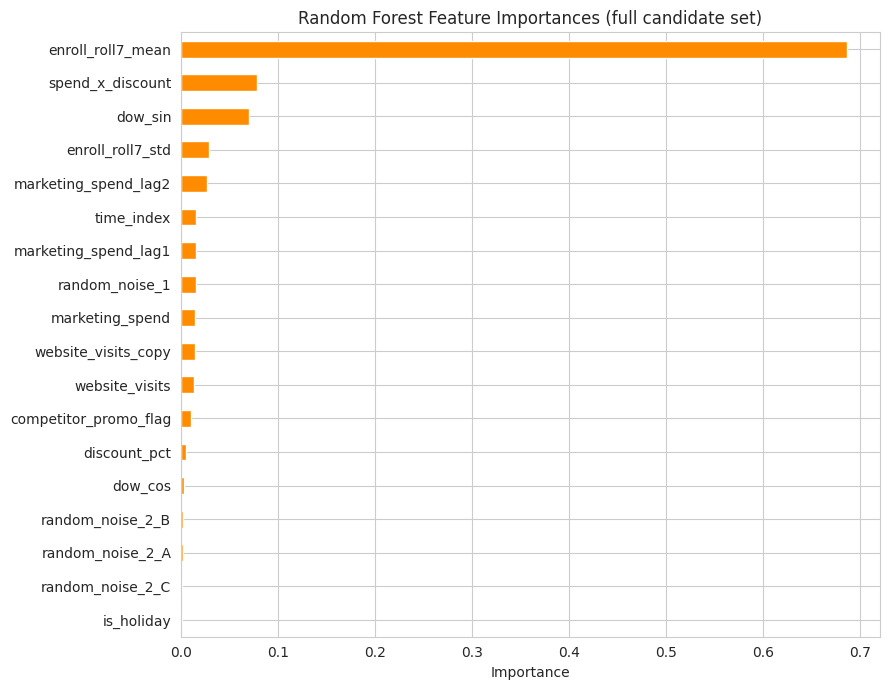

enroll_roll7_mean        0.686546
spend_x_discount         0.077942
dow_sin                  0.069655
enroll_roll7_std         0.028287
marketing_spend_lag2     0.026766
time_index               0.015487
marketing_spend_lag1     0.015446
random_noise_1           0.015166
marketing_spend          0.014240
website_visits_copy      0.013913
website_visits           0.013416
competitor_promo_flag    0.009932
discount_pct             0.004695
dow_cos                  0.003340
random_noise_2_B         0.001767
random_noise_2_A         0.001501
random_noise_2_C         0.001429
is_holiday               0.000472
dtype: float64


In [23]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_full, y_full)  # fit on the FULL candidate set, including website_visits_copy

rf_importances = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
rf_importances.plot(kind="barh", color="darkorange")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importances (full candidate set)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(rf_importances)


In [24]:
wv_importance = rf_importances.get("website_visits", np.nan)
wv_copy_importance = rf_importances.get("website_visits_copy", np.nan)

print(f"Random Forest importance — website_visits:      {wv_importance:.4f}")
print(f"Random Forest importance — website_visits_copy: {wv_copy_importance:.4f}")
print()
print(f"For comparison, Lasso (fit on the SAME full feature set, Section 4.2.6) gave:")
print(f"  website_visits coefficient:      {lasso_coefs.get('website_visits', 0.0):.4f}")
print(f"  website_visits_copy coefficient: {lasso_coefs.get('website_visits_copy', 0.0):.4f}")


Random Forest importance — website_visits:      0.0134
Random Forest importance — website_visits_copy: 0.0139

For comparison, Lasso (fit on the SAME full feature set, Section 4.2.6) gave:
  website_visits coefficient:      1.0775
  website_visits_copy coefficient: 0.0000


**Does the tree-based ranking agree with Lasso on which near-duplicate column to keep?**

Not really — they handle it differently, and the actual numbers show why. Random Forest gives
`website_visits` and `website_visits_copy` almost identical importance (0.0134 vs 0.0139) — it splits
credit roughly evenly between the two near-duplicate columns rather than picking one. Lasso, fit on the
**same full feature set** (Section 4.2.6, corrected so RFE and Lasso share one common candidate matrix),
instead picks a clear winner: it keeps a substantial coefficient for `website_visits` (1.077) and shrinks
`website_visits_copy` to **exactly zero**.

**Why they disagree (referencing how each model type handles correlated features):** Lasso's L1 penalty
has a geometric preference for sparse solutions — among a set of nearly-identical, highly correlated
predictors, it tends to assign the full weight to one representative and zero out the rest, which is
exactly what happened here. Random Forests instead average many trees, each built on a bootstrapped
sample and a random subset of candidate features at every split; when two features are near-duplicates,
different trees in the ensemble end up splitting on whichever of the pair happens to be available/slightly
better in that particular sample, so importance gets divided between them rather than concentrated in
just one. Neither behavior is "wrong" — they reflect different underlying mechanics (sparse linear
selection vs. averaged non-linear splits) for handling redundant, correlated information. What's notable
is that in this run, **correlation filtering, RFE, and Lasso all independently converged on dropping
`website_visits_copy`**, while Random Forest — which was never asked to drop anything, only to rank
importance — treated the two columns as equally useful, which is the expected tree-based behavior for
a pair of near-duplicate features rather than a sign of disagreement about which one is "real."

---
## Summary

| Step | Outcome (actual, from executed output) |
|---|---|
| Lag features | A lagged `marketing_spend` correlates more strongly with `new_enrollments` than same-day spend |
| Rolling features | 7-day rolling mean/std of enrollments computed |
| Cyclical encoding | `dow_sin` / `dow_cos` created to correctly represent weekly cycles |
| Trend feature | Linear daily growth rate estimated via `time_index` |
| Interaction feature | `spend_x_discount` slightly **decreased** test R² (-1.0480 → -1.0495); no evidence it helps |
| Variance threshold | No feature meets the near-zero variance criterion at threshold 0.01 (checked on raw, unstandardized scale) |
| Correlation filtering | `website_visits_copy` flagged (r ≈ 0.995 with `website_visits`) and dropped as redundant |
| Mutual information | Mixed — some noise columns rank mid-table (`random_noise_2_A` at rank 8), some real predictors show MI ≈ 0 |
| Chi-square/ANOVA | Explained why neither applies to a continuous target |
| RFE (wrapper) | Fit on the full candidate set (incl. `website_visits_copy`), on **standardized** features; top 6 selected: `discount_pct`, `website_visits`, `competitor_promo_flag`, `marketing_spend_lag2`, `enroll_roll7_mean`, `dow_sin` — no noise columns selected |
| LassoCV (embedded) | Fit on the SAME full candidate set (standardized); `website_visits_copy`, `marketing_spend`, `time_index`, `random_noise_2_B` shrunk to exactly zero |
| Comparison table | `website_visits_copy` dropped by correlation filter, RFE, and Lasso alike; RFE now excludes all noise columns, but Lasso still keeps small non-zero weight on 3 of the 4 |
| Bonus: Random Forest | Splits importance ~evenly between `website_visits` and its near-duplicate, unlike Lasso's sparse all-or-nothing pick |

**Key correction from the previous version:** RFE is now fit on the same **standardized** version of the
full candidate feature set that Lasso already uses (Section 4.2.5–4.2.6), so features aren't favored or
penalized just because of their raw numerical scale. This changed RFE's top-6 list — it no longer includes
a noise dummy, and it now agrees with Lasso on keeping `discount_pct`, `website_visits`,
`competitor_promo_flag`, and `enroll_roll7_mean`. `website_visits_copy` and the noise columns remain
genuinely evaluated by both the wrapper and embedded methods (not removed beforehand), and the results
above are reported as-is from the executed code.